# Assignment 3 

Dataset: Twitch Gamers social network: 
This is a mutual follower network of streamers on twitch. https://snap.stanford.edu/data/twitch_gamers.html
Ive always been interested in gaming and streaming games so I decided to analyse this dataset and look for interesting patterns

The full graph has 168 thousand nodes and 6 million edges, which is of course too big of a scope to handle so this notebook takes a smaller connected sample and analyzes that instead.

## Description

Twitch is a livestreaming platform where people broadcast themselves playing games to viewers in real time, and streamers can follow each other just like on any other social platform. In this dataset, each node is a streamer, and each edge means two streamers follow each other back, so its a mutual relationship rather than a one way follow. There's also some extra info per streamer like view count,language and whether theyre flagged for mature content. You can look at whether being well connected actually lines up with being popular, and whether a few streamers act as hubs holding the network together.

## 1. Setup

In [27]:
from collections import defaultdict, deque

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Load the data and take a sample

A random slice of edges would scatter disconnected fragments everywhere so instead this grows outward from one starting user through real follower connections until 500 users are collected. Basically a breadth first approach that keeps the sample connected and realistic.

In [28]:
edges = pd.read_csv("large_twitch_edges.csv")
print("Full graph - nodes:", pd.unique(edges[["numeric_id_1", "numeric_id_2"]].values.ravel()).shape[0],
      " edges:", len(edges))

adjacency = defaultdict(list)
for a, b in zip(edges["numeric_id_1"], edges["numeric_id_2"]):
    adjacency[a].append(b)
    adjacency[b].append(a)

start_node = 62841
sample_ids = {start_node}
queue = deque([start_node])
while queue and len(sample_ids) < 500:
    node = queue.popleft()
    for neighbor in adjacency[node]:
        if neighbor not in sample_ids:
            sample_ids.add(neighbor)
            queue.append(neighbor)
            if len(sample_ids) >= 500:
                break

sample_edges = edges[edges["numeric_id_1"].isin(sample_ids) & edges["numeric_id_2"].isin(sample_ids)]
G = nx.from_pandas_edgelist(sample_edges, "numeric_id_1", "numeric_id_2")

print("Sample - nodes:", G.number_of_nodes(), " edges:", G.number_of_edges())

Full graph - nodes: 168114  edges: 6797557
Sample - nodes: 500  edges: 3149


## Confirming that its connected

In [29]:
print("Connected components :", nx.number_connected_components(G))
print("Isolated nodes       :", list(nx.isolates(G)))

Connected components : 1
Isolated nodes       : []


As expected we have one connected and no isolated nodes. Because the BFS is only supposed to reach users through existing edges.

## Visualizing our sample

Node size reflects degree (more connections = bigger).

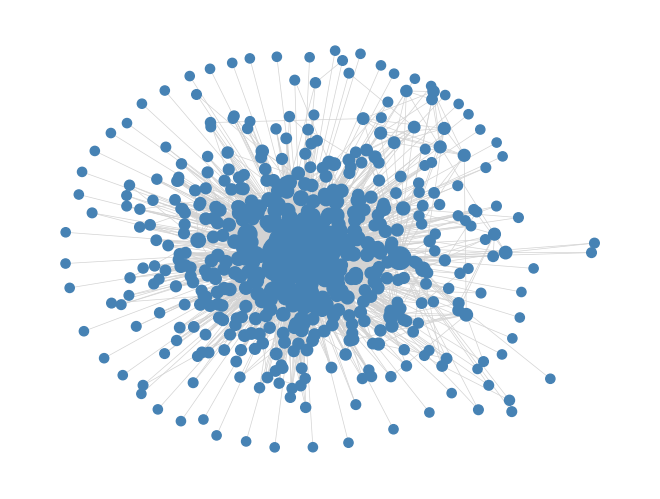

In [30]:
degrees = dict(G.degree())
pos = nx.spring_layout(G, k=0.3, seed=42)
nx.draw(G, pos, node_size=[40 + 4 * degrees[n] for n in G],
        node_color="steelblue", edge_color="lightgray", width=0.5)

plt.show()

## Diameter and clustering coefficient

The diameter of the graph tells us the longest one of all the shortest path in the graph between nodes. Basically how spread out the network is. A smaller diameter meanths the network is more tightly knit, everyone is close to everyone else, and if the number is big that means it takes more jumps to go from one node to another. This is like the famous 6 degrees of seperation idea that says any two people are connected trough at most 6 mutual aquaintances 

Clustering coefficient for a given node, it looks at that nodes connections and asks how many of them are also connected to each other. So if you follow two other streamers, are those two streamers also following each other, or are they totally unrelated? Averaged across the whole graph this tells you whether the network is made up of tight little friend groups or whether it's more spread out and random.


In [31]:
print("Diameter :", nx.diameter(G))
print("Average clustering coefficient :", round(nx.average_clustering(G), 3))

Diameter : 3
Average clustering coefficient : 0.46


So in our sample the diameter came out to 3. Meaning any two users are connected through at most 3 hops. Thats a pretty small world. The clustering coefficient came out to about 0.46, which is fairly high so a users followers tend to also follow each other forming these tight little groups instead of just random scattered connections.

One thing worth pointing out though.since we used BFS sampling it tends to grab high degree nodes early on which kind of inflates the clustering and shrinks the diameter compared to what you might actually see in the full 168000 node graph. So these numbers are a good description of our sample specifically not a precise measurement of the whole platform.

## Degree histogram

This tells us how are connections spread across the 500 sampled users

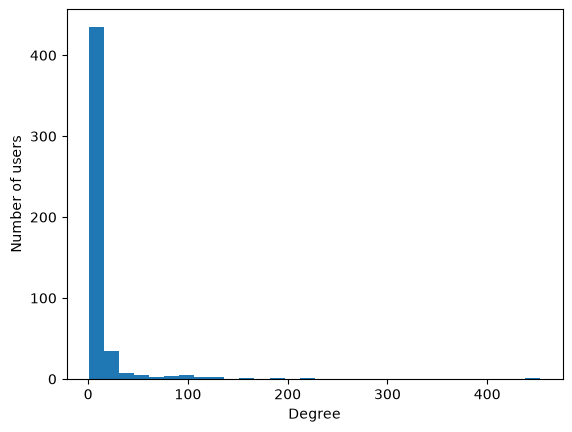

count    500.000000
mean      12.596000
std       29.569266
min        1.000000
25%        3.000000
50%        6.000000
75%       11.000000
max      453.000000
Name: degree, dtype: float64


In [32]:
degrees = pd.Series(dict(G.degree()), name="degree")
plt.hist(degrees, bins=30)
plt.xlabel("Degree")
plt.ylabel("Number of users")
plt.show()
print(degrees.describe())

Looking at the histogram most users in the sample only have a handful of connections, with a median of 6, while a few have over a hundred. This tells us the connections in this network arent spread out evenly. A small number of streamers are way more connected than everyone else while the majority just have a few mutual follows.It means a tiny group of well connected streamers could end up having an outsized influence on the whole network, even though most people in it are only loosely connected. Its likely the full 168 thousand node graph follows a similar pattern, since these kinds of distributions are really common in real social networks

## Does connectivity relate to popularity?

We can do a join from sample to the full dataset to get the views gotten by the streamers and check whether better connected streamers also get more views.

Correlation between degree and views: 0.65


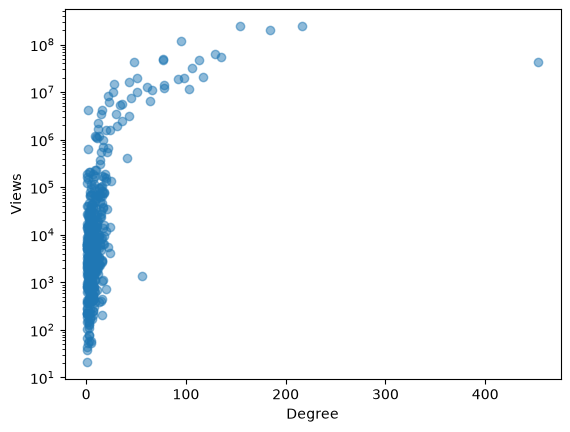

In [33]:
features = pd.read_csv("large_twitch_features.csv").set_index("numeric_id")
sample_features = features.loc[list(sample_ids)].join(degrees)
correlation = sample_features["degree"].corr(sample_features["views"])
print(f"Correlation between degree and views: {correlation:.2f}")
plt.scatter(sample_features["degree"], sample_features["views"], alpha=0.5)
plt.yscale("log")
plt.xlabel("Degree")
plt.ylabel("Views")
plt.show()

Looking at the scatter plot theres a pretty clear pattern. Streamers with more mutual connections tend to have way more views and the correlation came out to about 0.65 which is a fairly strong relationship. But its not a straight line the whole way through. Below about 50 connections views are all over the place. Some of those low degree streamers have barely any views while others have hundreds of thousands. Once you get past 100 or so connections though almost every streamer is sitting in the millions of views range.

What this probably means is that being well connected isnt just a side effect of being popular its more likely a big part of how people actually get discovered on twitch in the first place. If other streamers follow you their viewers are more likely to stumble onto your channel too so connections end up working like a discovery network and not just a social graph. Im guessing twitch uses this graph to run their recommender algorithm to filter out actual verified users who are well connected instead of possible new but untested users. But this also means discovery in the initial stages could be hard. Visibility snowballs after the 50 -60 connection range but getting there will be a hard mountain to climb. It also shows us how sometimes its who you know rather than what you know or create.  


There are a couple outliers. Theres one streamer with a decent number of connections around 50 to 60, but way fewer views than youd expect for that degree. Theres also the streamer with the highest degree in the whole sample over 450 connections but their view count is actually lower than several streamers with less than half as many connections. So being extremely well connected doesnt automatically mean youll have the most views. It probably means connections help a lot on average but individual factors like probably how often someone streams and type of content they make, or even how active they are still matter a lot too. Those two outliers are a good reminder that degree is a strong predictor but its not the whole story.



## How do newcomers do?

Lets say I wanted to get into twitch streaming. Id be interested in knowing if the discovery loop is biased towards older well connected users. There is a feature called Lifetime in the dataset that tells us how long each account has existed. Splitting the sample into the youngest 25% of accounts and the oldest 25% shows whether newer streamers are at an actual statistical disadvantage when it comes to connections and views.

In [35]:
sample_features = features.loc[list(sample_ids)].join(degrees)

newcomers = sample_features[sample_features["life_time"] <= sample_features["life_time"].quantile(0.25)]
established = sample_features[sample_features["life_time"] >= sample_features["life_time"].quantile(0.75)]

print("Newcomers")
print("median degree:", newcomers["degree"].median())
print("median views :", newcomers["views"].median())
print()
print("Established")
print("median degree:", established["degree"].median())
print("median views :", established["views"].median())
print()


Newcomers
median degree: 4.0
median views : 2309.0

Established
median degree: 11.0
median views : 27804.0



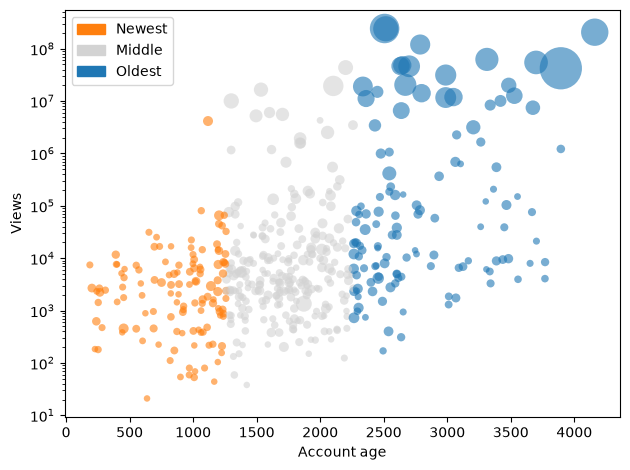

In [38]:
q25, q75 = sample_features["life_time"].quantile([0.25, 0.75])
colors = ["tab:orange" if lt <= q25 else "tab:blue" if lt >= q75 else "lightgray"
          for lt in sample_features["life_time"]]

plt.scatter(sample_features["life_time"], sample_features["views"],
            s=20 + sample_features["degree"] * 2, c=colors, alpha=0.6, edgecolors="none")
plt.yscale("log")
plt.xlabel("Account age")
plt.ylabel("Views" )

import matplotlib.patches as mpatches
handles = [mpatches.Patch(color="tab:orange", label="Newest"),
           mpatches.Patch(color="lightgray", label="Middle"),
           mpatches.Patch(color="tab:blue", label="Oldest")]
plt.legend(handles=handles)
plt.tight_layout()
plt.show()

This plot highlights the newest 25% of accounts in orange and the oldest 25% in blue with everyone else in gray. The orange points are packed into the bottom left corner. Small bubbles and low views, with barely any of them breaking past 10000 views. Comparing that to the blue points, which are spread across the top of the plot with the biggest bubbles in the whole sample. There is a little overlap, a few orange points do climb higher than youd expect, so its not completely impossible to gain traction early. But the color split makes it pretty clear that newcomers are starting from way behind, both in connections and in views, and it takes real time on the platform to catch up.

## Summary

- Full graph: 168 thousand streamers, almost 7 million connections. We took a 500 person sample, bfs so  fully connected, no isolated users
- Diameter of 3 and clustering coefficient of about 0.46, short paths plus tight friend groups
- Most streamers have only a handful of connections and a small number act as hubs holding the network together
- Degree and views correlated at about 0.65. More connected streamers tend to have more views but its not a perfect relationship
- Newer accounts are clearly at a disadvantage, low degree and low views across the board though a few did break out early
- Overall time on the platform and connections made both seem to matter a lot for visibility on Twitch
